# 94 — Match nodal individual events to Geode stack metadata

This notebook assigns individual nodal events to Geode stacked shot records.

For Geode surveys, Jochen's spreadsheet is the source-position truth. Nodal energy-derived source position is used as a diagnostic residual, not as the primary source location.

Matching is driven by corrected Geode stack timing windows:

- Geode stacked-file time = final trigger in stack
- stack window extends backwards from the corrected final-trigger time
- candidate nodal events must fall within that window and have a source-position estimate close to the spreadsheet source position

Inputs:

- `geode_events` from `92_build_geode_shot_catalog_from_excel.ipynb`
- `nodal_source_estimates` from `93_estimate_nodal_source_positions.ipynb`

Outputs/replaces:

- `geode_nodal_event_matches`
- `geode_nodal_stack_match_summary`
- `geode_nodal_unmatched_stacks`

## 1. Configuration

In [1]:
from pathlib import Path
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/Volumes/tachyon/LBSSP_DATA")
CATALOG_DB = PROJECT_ROOT / "catalog" / "lbssp_shot_catalog.sqlite"
# sqlite3 can create a database file, but not a missing parent directory.
CATALOG_DB.parent.mkdir(parents=True, exist_ok=True)

OUT_ROOT = PROJECT_ROOT / "nodal_geode_match_exports"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# Set one survey for focused testing, or None for all Geode surveys.
TARGET_SURVEY = None
# TARGET_SURVEY = "T1_1m_refraction"
# TARGET_SURVEY = "T1_streamer_masw"

SOURCE_TOLERANCE_M = 4.0
TIME_MARGIN_BEFORE_S = 0.0
TIME_MARGIN_AFTER_S = 0.0

AUTO_ACCEPT_MAX_SOURCE_RESID_M = 3.0
AUTO_ACCEPT_MAX_ABS_FINAL_TIME_S = 180.0

WRITE_TABLES = True

print("CATALOG_DB:", CATALOG_DB)
print("OUT_ROOT:", OUT_ROOT)
print("TARGET_SURVEY:", TARGET_SURVEY)

CATALOG_DB: /Volumes/tachyon/LBSSP_DATA/catalog/lbssp_shot_catalog.sqlite
OUT_ROOT: /Volumes/tachyon/LBSSP_DATA/nodal_geode_match_exports
TARGET_SURVEY: None


## Database safety preflight

In [2]:
# ---- Database safety preflight (94 Geode↔nodal match notebook) ----
# 94 reads 92_* and 93_* tables and creates/replaces only its own match tables.
from pathlib import Path
import sqlite3
import pandas as pd

CATALOG_DB = Path(CATALOG_DB)
if not CATALOG_DB.exists():
    raise FileNotFoundError(
        f"Catalog database not found: {CATALOG_DB}\n"
        "Run 90_*, 92_*, and 93_* first."
    )

with sqlite3.connect(CATALOG_DB) as _conn:
    _tables = pd.read_sql(
        """
        SELECT name
        FROM sqlite_master
        WHERE type='table'
        ORDER BY name
        """,
        _conn,
    )["name"].tolist()

REQUIRED_INPUT_TABLES = [
    "shot_events",
    "shot_gather_files",
    "trace_index",
    "geode_events",
    "geode_time_models",
    "nodal_source_estimates",
]

missing = [t for t in REQUIRED_INPUT_TABLES if t not in _tables]
if missing:
    raise RuntimeError(
        f"Catalog exists, but required input tables are missing: {missing}"
    )

NOTEBOOK_94_TABLES = [
    "geode_nodal_event_matches",
    "geode_nodal_stack_match_summary",
    "geode_nodal_unmatched_stacks",
]

print("Input catalog checked:", CATALOG_DB)
print("Required 90/92/93 tables present.")
print("94 will only create/replace:", NOTEBOOK_94_TABLES)

Input catalog checked: /Volumes/tachyon/LBSSP_DATA/catalog/lbssp_shot_catalog.sqlite
Required 90/92/93 tables present.
94 will only create/replace: ['geode_nodal_event_matches', 'geode_nodal_stack_match_summary', 'geode_nodal_unmatched_stacks']


## 2. Load catalog tables

In [3]:
conn = sqlite3.connect(CATALOG_DB)

tables = pd.read_sql(
    '''
    SELECT name
    FROM sqlite_master
    WHERE type='table'
    ORDER BY name
    ''',
    conn,
)
display(tables)

required = ["geode_events", "nodal_source_estimates", "shot_events", "shot_gather_files", "trace_index"]
missing = [t for t in required if t not in set(tables["name"])]
if missing:
    raise RuntimeError(f"Missing required tables: {missing}. Run 90, 92, and 93 first.")

geode_events = pd.read_sql("SELECT * FROM geode_events", conn)
nodal_est = pd.read_sql("SELECT * FROM nodal_source_estimates", conn)
shot_events = pd.read_sql("SELECT * FROM shot_events WHERE instrument_system='nodal'", conn)
shot_gather_files = pd.read_sql("SELECT * FROM shot_gather_files WHERE instrument_system='nodal'", conn)
trace_index = pd.read_sql("SELECT * FROM trace_index WHERE instrument_system='nodal'", conn)

print("geode_events:", len(geode_events))
print("nodal_source_estimates:", len(nodal_est))
print("nodal shot_events:", len(shot_events))
print("shot_gather_files:", len(shot_gather_files))
print("trace_index:", len(trace_index))

,name
0,geode_catalog_sheet_diagnostics
1,geode_events
2,geode_nodal_event_matches
3,geode_nodal_stack_match_summary
4,geode_nodal_unmatched_stacks
5,geode_time_models
6,nodal_geode_stack_candidates
7,nodal_geode_stack_summary
8,nodal_source_estimate_failures
9,nodal_source_estimates


geode_events: 242
nodal_source_estimates: 3436
nodal shot_events: 3436
shot_gather_files: 3436
trace_index: 338580


## 3. Normalize times and numeric fields

In [4]:
for col in ["stack_start_utc", "stack_end_utc", "geode_final_trigger_time_utc"]:
    if col in geode_events.columns:
        geode_events[col.replace("_utc", "_dt")] = pd.to_datetime(
            geode_events[col],
            errors="coerce",
            utc=True,
        )

geode_events["source_x_m"] = pd.to_numeric(geode_events["source_x_m"], errors="coerce")
geode_events["file_no"] = pd.to_numeric(geode_events["file_no"], errors="coerce")
geode_events["n_stack_shots"] = pd.to_numeric(geode_events["n_stack_shots"], errors="coerce")

nodal_est["event_time_dt"] = pd.to_datetime(nodal_est["event_time_utc"], errors="coerce", utc=True)
nodal_est["estimated_source_x_m"] = pd.to_numeric(nodal_est["estimated_source_x_m"], errors="coerce")

geode_use = geode_events.dropna(
    subset=["stack_start_dt", "stack_end_dt", "source_x_m"]
).copy()
nodal_use = nodal_est.dropna(
    subset=["event_time_dt", "estimated_source_x_m"]
).copy()

if TARGET_SURVEY is not None:
    geode_use = geode_use[geode_use["survey"].astype(str).eq(TARGET_SURVEY)].copy()

print("usable geode_events:", len(geode_use))
print("usable nodal source estimates:", len(nodal_use))

display(geode_use.groupby(["survey", "line"], dropna=False).size().reset_index(name="n_geode_stacks"))
display(nodal_use.groupby("timewindow_label", dropna=False).size().reset_index(name="n_nodal_events"))

usable geode_events: 236
usable nodal source estimates: 3431


,survey,line,n_geode_stacks
0,T1_1m_refraction,T1,42
1,T1_2m_refraction,T1,42
2,T1_streamer_masw,T1,83
3,T3_1m_refraction,T3,39
4,T4_1m_refraction,T4,30


,timewindow_label,n_nodal_events
0,T1_N1_Streamer,532
1,T1_N2_Nodal1,1374
2,T1_N2_Nodal2,81
3,T1_N2_Refraction1m,429
4,T1_N2_Refraction2m,450
5,T1_N3_Nodal3,43
6,T3_N4_Refraction1am,522


## 4. Candidate matching logic

In [5]:
def score_match(time_from_final_s, source_x_residual_m, in_stack_window=True):
    '''Higher is better. Uses source-position residual as diagnostic and ranking aid.'''
    score = 0.0

    if in_stack_window:
        score += 10.0

    if np.isfinite(source_x_residual_m):
        score += max(0.0, 5.0 - abs(source_x_residual_m))

    # Valid stack members are usually negative time_from_final_s because the
    # Geode time is the final trigger in the stack.
    if np.isfinite(time_from_final_s):
        score += max(0.0, 5.0 - abs(time_from_final_s) / 30.0)

    return float(score)


def classify_match(source_x_residual_m, time_from_final_s):
    if not np.isfinite(source_x_residual_m):
        return "review_no_source_estimate"
    if (
        abs(source_x_residual_m) <= AUTO_ACCEPT_MAX_SOURCE_RESID_M
        and abs(time_from_final_s) <= AUTO_ACCEPT_MAX_ABS_FINAL_TIME_S
    ):
        return "accepted_auto"
    if abs(source_x_residual_m) <= SOURCE_TOLERANCE_M:
        return "review_position_ok"
    return "rejected_position"

## 5. Build Geode↔nodal event candidate table

In [6]:
rows = []

for _, g in geode_use.iterrows():

    start = g["stack_start_dt"] - pd.to_timedelta(TIME_MARGIN_BEFORE_S, unit="s")
    end = g["stack_end_dt"] + pd.to_timedelta(TIME_MARGIN_AFTER_S, unit="s")
    source_truth = float(g["source_x_m"])

    cand = nodal_use.copy()

    # Prefer expected nodal time window from 92 metadata.
    tw = g.get("nodal_timewindow_label")
    if isinstance(tw, str) and tw and tw.lower() not in ["none", "nan"]:
        cand_tw = cand[cand["timewindow_label"].astype(str).eq(tw)].copy()
        if len(cand_tw):
            cand = cand_tw

    # Same line where available.
    if isinstance(g.get("line"), str) and "line" in cand.columns:
        same_line = cand[cand["line"].astype(str).eq(str(g["line"]))].copy()
        if len(same_line):
            cand = same_line

    # Time window is primary for Geode surveys.
    cand = cand[
        (cand["event_time_dt"] >= start) &
        (cand["event_time_dt"] <= end)
    ].copy()

    if cand.empty:
        continue

    cand["source_x_truth_m"] = source_truth
    cand["source_x_residual_m"] = cand["estimated_source_x_m"] - source_truth
    cand["abs_source_x_residual_m"] = cand["source_x_residual_m"].abs()

    # Source estimate is a diagnostic filter/ranking aid.
    cand = cand[cand["abs_source_x_residual_m"] <= SOURCE_TOLERANCE_M].copy()

    for _, n in cand.iterrows():
        final_dt = g.get("geode_final_trigger_time_dt", pd.NaT)
        time_from_final_s = (
            (n["event_time_dt"] - final_dt).total_seconds()
            if pd.notna(final_dt)
            else np.nan
        )

        status = classify_match(n["source_x_residual_m"], time_from_final_s)
        score = score_match(time_from_final_s, n["source_x_residual_m"], True)

        rows.append({
            "geode_event_id": g["geode_event_id"],
            "geode_survey": g["survey"],
            "line": g["line"],
            "file_no": int(g["file_no"]) if np.isfinite(g["file_no"]) else None,
            "source_type": g.get("source_type"),
            "n_stack_shots": int(g["n_stack_shots"]) if np.isfinite(g["n_stack_shots"]) else None,
            "source_x_truth_m": source_truth,
            "geode_final_trigger_time_utc": g.get("geode_final_trigger_time_utc"),
            "stack_start_utc": g.get("stack_start_utc"),
            "stack_end_utc": g.get("stack_end_utc"),
            "geode_clock_correction_s": g.get("geode_clock_correction_s"),
            "geode_file_time_meaning": g.get("geode_file_time_meaning"),

            "nodal_event_id": n["event_id"],
            "nodal_timewindow_label": n["timewindow_label"],
            "nodal_event_time_utc": n["event_time_utc"],
            "nodal_event_time_method": n.get("event_time_method"),
            "estimated_source_x_m": n["estimated_source_x_m"],
            "source_x_method": n.get("source_x_method"),
            "source_x_residual_m": n["source_x_residual_m"],
            "abs_source_x_residual_m": n["abs_source_x_residual_m"],
            "time_from_final_trigger_s": time_from_final_s,
            "match_score": score,
            "match_status": status,
            "accepted": status.startswith("accepted"),
            "mseed_path": n.get("mseed_path"),
            "top_energy_receivers_json": n.get("top_energy_receivers_json"),
        })

matches = pd.DataFrame(rows)

print("candidate matches:", len(matches))
if len(matches):
    display(matches.head())
    display(matches["match_status"].value_counts(dropna=False))
else:
    print("No matches found.")

candidate matches: 886


,geode_event_id,geode_survey,line,file_no,source_type,n_stack_shots,source_x_truth_m,geode_final_trigger_time_utc,stack_start_utc,stack_end_utc,...,estimated_source_x_m,source_x_method,source_x_residual_m,abs_source_x_residual_m,time_from_final_trigger_s,match_score,match_status,accepted,mseed_path,top_energy_receivers_json
0,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,3006,hammer,9,84.5,2026-05-18T16:08:31+00:00,2026-05-18T16:07:43+00:00,2026-05-18T16:08:33+00:00,...,83.821893,weighted_top3_energy_hp25,-0.678107,0.678107,-46.990,17.755560,accepted_auto,True,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,"[{""seed_id"": ""T1.08405.N2.DPZ"", ""station"": ""08..."
1,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,3006,hammer,9,84.5,2026-05-18T16:08:31+00:00,2026-05-18T16:07:43+00:00,2026-05-18T16:08:33+00:00,...,83.970530,weighted_top3_energy_hp25,-0.529470,0.529470,-37.576,18.217997,accepted_auto,True,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,"[{""seed_id"": ""T1.08405.N2.DPZ"", ""station"": ""08..."
2,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,3006,hammer,9,84.5,2026-05-18T16:08:31+00:00,2026-05-18T16:07:43+00:00,2026-05-18T16:08:33+00:00,...,83.864182,weighted_top3_energy_hp25,-0.635818,0.635818,-30.986,18.331316,accepted_auto,True,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,"[{""seed_id"": ""T1.08405.N2.DPZ"", ""station"": ""08..."
3,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,3006,hammer,9,84.5,2026-05-18T16:08:31+00:00,2026-05-18T16:07:43+00:00,2026-05-18T16:08:33+00:00,...,84.035583,weighted_top3_energy_hp25,-0.464417,0.464417,-24.402,18.722183,accepted_auto,True,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,"[{""seed_id"": ""T1.08405.N2.DPZ"", ""station"": ""08..."
4,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,3006,hammer,9,84.5,2026-05-18T16:08:31+00:00,2026-05-18T16:07:43+00:00,2026-05-18T16:08:33+00:00,...,84.031521,weighted_top3_energy_hp25,-0.468479,0.468479,-17.596,18.944988,accepted_auto,True,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,"[{""seed_id"": ""T1.08405.N2.DPZ"", ""station"": ""08..."


match_status
accepted_auto         864
review_position_ok     22
Name: count, dtype: int64

## 6. Stack-level summary

In [7]:
if len(matches):
    stack_summary = (
        matches
        .groupby(
            [
                "geode_event_id",
                "geode_survey",
                "line",
                "file_no",
                "source_x_truth_m",
                "source_type",
                "n_stack_shots",
            ],
            dropna=False,
        )
        .agg(
            n_candidate_events=("nodal_event_id", "count"),
            n_accepted_auto=("accepted", "sum"),
            first_nodal_time_utc=("nodal_event_time_utc", "min"),
            last_nodal_time_utc=("nodal_event_time_utc", "max"),
            median_source_x_residual_m=("source_x_residual_m", "median"),
            median_abs_source_x_residual_m=("abs_source_x_residual_m", "median"),
            min_time_from_final_s=("time_from_final_trigger_s", "min"),
            max_time_from_final_s=("time_from_final_trigger_s", "max"),
            best_match_score=("match_score", "max"),
        )
        .reset_index()
        .sort_values(["geode_survey", "file_no", "source_x_truth_m"])
    )
else:
    stack_summary = pd.DataFrame()

display(stack_summary.head(100))

,geode_event_id,geode_survey,line,file_no,source_x_truth_m,source_type,n_stack_shots,n_candidate_events,n_accepted_auto,first_nodal_time_utc,last_nodal_time_utc,median_source_x_residual_m,median_abs_source_x_residual_m,min_time_from_final_s,max_time_from_final_s,best_match_score
0,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,3006,84.5,hammer,9,6,6,2026-05-18T16:07:44.010000+00:00,2026-05-18T16:08:30.714000+00:00,-0.520314,0.520314,-46.990,-0.286,19.479308
1,GEODE_T1_1M_REFRACTION_F3008,T1_1m_refraction,T1,3008,88.5,hammer,9,3,3,2026-05-18T16:18:11.590000+00:00,2026-05-18T16:18:25.676000+00:00,-0.158460,0.158460,-21.410,-7.324,19.597407
2,GEODE_T1_1M_REFRACTION_F3009,T1_1m_refraction,T1,3009,90.5,hammer,9,7,7,2026-05-18T16:20:09.242000+00:00,2026-05-18T16:20:52.060000+00:00,1.512838,1.512838,-42.758,0.060,18.496037
3,GEODE_T1_1M_REFRACTION_F3010,T1_1m_refraction,T1,3010,92.5,hammer,10,2,2,2026-05-18T16:25:40.704000+00:00,2026-05-18T16:25:50.720000+00:00,-0.369446,0.369446,-43.296,-33.280,18.519485
4,GEODE_T1_1M_REFRACTION_F3011,T1_1m_refraction,T1,3011,94.5,hammer,9,6,6,2026-05-18T16:35:47.448000+00:00,2026-05-18T16:36:33.668000+00:00,-0.052922,0.076996,-46.552,-0.332,19.914386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,GEODE_T1_STREAMER_MASW_F1030,T1_streamer_masw,T1,1030,130.5,PEG,4,3,3,2026-05-16T19:48:59.884000+00:00,2026-05-16T19:49:22.998000+00:00,0.166140,0.166140,-23.116,-0.002,19.897484
96,GEODE_T1_STREAMER_MASW_F1031,T1_streamer_masw,T1,1031,132.0,PEG,3,3,3,2026-05-16T19:50:36.476000+00:00,2026-05-16T19:50:53.592000+00:00,-0.504613,0.504613,-16.524,0.592,19.581810
97,GEODE_T1_STREAMER_MASW_F1032,T1_streamer_masw,T1,1032,133.5,PEG,3,2,2,2026-05-16T19:53:40.580000+00:00,2026-05-16T19:53:51.420000+00:00,-1.766495,1.766495,-10.420,0.420,18.313350
98,GEODE_T1_STREAMER_MASW_F1033,T1_streamer_masw,T1,1033,135.0,PEG,5,5,5,2026-05-16T19:55:53.402000+00:00,2026-05-16T19:56:24.666000+00:00,-0.588040,0.588040,-31.598,-0.334,19.671382


## 7. QC: which Geode stacks were missed?

In [8]:
if len(stack_summary):
    matched_geode_ids = set(stack_summary["geode_event_id"].astype(str))
else:
    matched_geode_ids = set()

missed = geode_use[~geode_use["geode_event_id"].astype(str).isin(matched_geode_ids)].copy()

print("Geode stacks:", len(geode_use))
print("Matched stacks:", len(matched_geode_ids))
print("Missed stacks:", len(missed))

cols = [
    "geode_event_id",
    "survey",
    "line",
    "file_no",
    "source_x_m",
    "geode_final_trigger_time_utc",
    "stack_start_utc",
    "stack_end_utc",
    "nodal_timewindow_label",
]
display(missed[[c for c in cols if c in missed.columns]].head(50))

Geode stacks: 236
Matched stacks: 185
Missed stacks: 51


,geode_event_id,survey,line,file_no,source_x_m,geode_final_trigger_time_utc,stack_start_utc,stack_end_utc,nodal_timewindow_label
4,GEODE_T1_1M_REFRACTION_F3005,T1_1m_refraction,T1,3005.0,82.5,2026-05-18T16:03:43+00:00,2026-05-18T16:02:55+00:00,2026-05-18T16:03:45+00:00,T1_N2_Refraction1m
6,GEODE_T1_1M_REFRACTION_F3007,T1_1m_refraction,T1,3007.0,86.5,2026-05-18T16:13:30+00:00,2026-05-18T16:12:42+00:00,2026-05-18T16:13:32+00:00,T1_N2_Refraction1m
14,GEODE_T1_1M_REFRACTION_F3015,T1_1m_refraction,T1,3015.0,102.5,2026-05-18T16:55:31+00:00,2026-05-18T16:54:43+00:00,2026-05-18T16:55:33+00:00,T1_N2_Refraction1m
46,GEODE_T1_2M_REFRACTION_F3047,T1_2m_refraction,T1,3047.0,43.0,2026-05-18T20:18:33+00:00,2026-05-18T20:17:39+00:00,2026-05-18T20:18:35+00:00,T1_N2_Refraction2m
47,GEODE_T1_2M_REFRACTION_F3048,T1_2m_refraction,T1,3048.0,47.0,2026-05-18T20:21:33+00:00,2026-05-18T20:20:39+00:00,2026-05-18T20:21:35+00:00,T1_N2_Refraction2m
48,GEODE_T1_2M_REFRACTION_F3049,T1_2m_refraction,T1,3049.0,51.0,2026-05-18T20:26:05+00:00,2026-05-18T20:25:11+00:00,2026-05-18T20:26:07+00:00,T1_N2_Refraction2m
49,GEODE_T1_2M_REFRACTION_F3050,T1_2m_refraction,T1,3050.0,55.0,2026-05-18T20:30:08+00:00,2026-05-18T20:29:14+00:00,2026-05-18T20:30:10+00:00,T1_N2_Refraction2m
50,GEODE_T1_2M_REFRACTION_F3051,T1_2m_refraction,T1,3051.0,59.0,2026-05-18T20:33:07+00:00,2026-05-18T20:32:13+00:00,2026-05-18T20:33:09+00:00,T1_N2_Refraction2m
51,GEODE_T1_2M_REFRACTION_F3052,T1_2m_refraction,T1,3052.0,63.0,2026-05-18T20:36:28+00:00,2026-05-18T20:35:34+00:00,2026-05-18T20:36:30+00:00,T1_N2_Refraction2m
77,GEODE_T1_2M_REFRACTION_F3078,T1_2m_refraction,T1,3078.0,167.0,2026-05-18T22:06:28+00:00,2026-05-18T22:05:34+00:00,2026-05-18T22:06:30+00:00,T1_N2_Refraction2m


## 8. Write match tables and CSV exports

In [9]:
# ---- Safe write of 94-owned tables only ----
# This cell intentionally drops/replaces only tables owned by notebook 94.
# It does not modify 90_* base tables, 92_* Geode tables, or 93_* source estimates.

NOTEBOOK_94_TABLES = [
    "geode_nodal_event_matches",
    "geode_nodal_stack_match_summary",
    "geode_nodal_unmatched_stacks",
]

REQUIRED_INPUT_TABLES = [
    "shot_events",
    "shot_gather_files",
    "trace_index",
    "geode_events",
    "geode_time_models",
    "nodal_source_estimates",
]

with sqlite3.connect(CATALOG_DB) as conn:
    existing_tables = pd.read_sql(
        """
        SELECT name
        FROM sqlite_master
        WHERE type='table'
        ORDER BY name
        """,
        conn,
    )["name"].tolist()

    missing_inputs = [t for t in REQUIRED_INPUT_TABLES if t not in existing_tables]
    if missing_inputs:
        raise RuntimeError(f"Refusing to write: input tables missing: {missing_inputs}")

    for table_name in NOTEBOOK_94_TABLES:
        conn.execute(f'DROP TABLE IF EXISTS "{table_name}"')

    matches.to_sql("geode_nodal_event_matches", conn, if_exists="fail", index=False)
    stack_summary.to_sql("geode_nodal_stack_match_summary", conn, if_exists="fail", index=False)
    missed.to_sql("geode_nodal_unmatched_stacks", conn, if_exists="fail", index=False)

    conn.commit()

matches.to_csv(OUT_ROOT / "geode_nodal_event_matches.csv", index=False)
stack_summary.to_csv(OUT_ROOT / "geode_nodal_stack_match_summary.csv", index=False)
missed.to_csv(OUT_ROOT / "geode_nodal_unmatched_stacks.csv", index=False)

print("CATALOG_DB:", CATALOG_DB)
print("Dropped/replaced only 94-owned SQLite tables:")
for t in NOTEBOOK_94_TABLES:
    print(" ", t)
print("CSV exports:", OUT_ROOT)

CATALOG_DB: /Volumes/tachyon/LBSSP_DATA/catalog/lbssp_shot_catalog.sqlite
Dropped/replaced only 94-owned SQLite tables:
  geode_nodal_event_matches
  geode_nodal_stack_match_summary
  geode_nodal_unmatched_stacks
CSV exports: /Volumes/tachyon/LBSSP_DATA/nodal_geode_match_exports


## 9. QC plot: nodal estimates, Geode stack windows, accepted matches

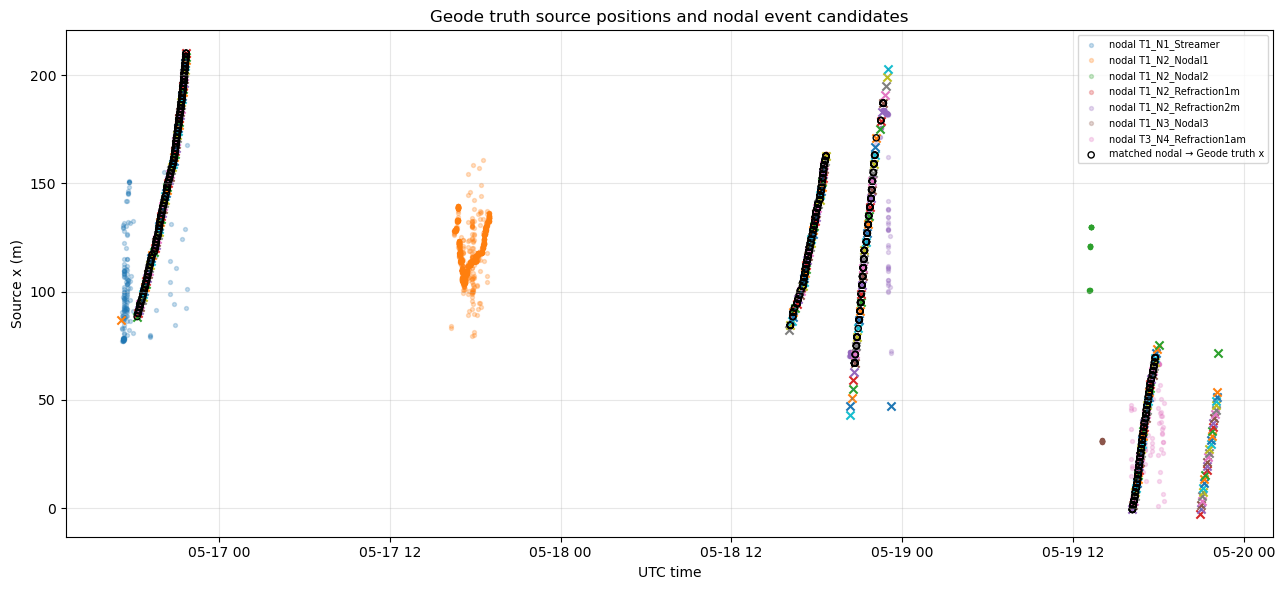

In [10]:
plot_n = nodal_use.copy()
plot_g = geode_use.copy()

fig, ax = plt.subplots(figsize=(13, 6))

# Raw nodal estimates.
for label, sub in plot_n.dropna(subset=["event_time_dt", "estimated_source_x_m"]).groupby("timewindow_label"):
    ax.scatter(
        sub["event_time_dt"],
        sub["estimated_source_x_m"],
        s=8,
        alpha=0.25,
        label=f"nodal {label}",
    )

# Geode stack windows and final trigger times.
for _, g in plot_g.dropna(subset=["stack_start_dt", "stack_end_dt", "source_x_m"]).iterrows():
    ax.hlines(g["source_x_m"], g["stack_start_dt"], g["stack_end_dt"], linewidth=2, alpha=0.8)
    if pd.notna(g.get("geode_final_trigger_time_dt", pd.NaT)):
        ax.scatter(
            [g["geode_final_trigger_time_dt"]],
            [g["source_x_m"]],
            marker="x",
            s=35,
        )

# Accepted or review-position-ok candidate matches.
if len(matches):
    m = matches[matches["match_status"].isin(["accepted_auto", "review_position_ok"])].copy()
    m["nodal_dt"] = pd.to_datetime(m["nodal_event_time_utc"], errors="coerce", utc=True)
    ax.scatter(
        m["nodal_dt"],
        m["source_x_truth_m"],
        s=20,
        marker="o",
        facecolors="none",
        edgecolors="black",
        label="matched nodal → Geode truth x",
    )

ax.set_title("Geode truth source positions and nodal event candidates")
ax.set_xlabel("UTC time")
ax.set_ylabel("Source x (m)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()

## 10. Focused table for one survey

In [11]:
if len(stack_summary):
    survey_counts = stack_summary.groupby("geode_survey").agg(
        n_stacks=("geode_event_id", "count"),
        total_candidates=("n_candidate_events", "sum"),
        total_auto_accepted=("n_accepted_auto", "sum"),
    ).reset_index()
else:
    survey_counts = pd.DataFrame()

display(survey_counts)

# Uncomment for focused inspection:
# display(stack_summary[stack_summary["geode_survey"].eq("T1_1m_refraction")].head(100))
# display(matches[matches["geode_survey"].eq("T1_1m_refraction")].head(100))

,geode_survey,n_stacks,total_candidates,total_auto_accepted
0,T1_1m_refraction,39,252,252
1,T1_2m_refraction,28,168,157
2,T1_streamer_masw,82,294,283
3,T3_1m_refraction,36,172,172
